In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
superstore = pd.read_excel('/content/US Superstore data.xls')
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Dataset Shape:", superstore.shape)
print("\nColumn Names:")
print(superstore.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [4]:
superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [5]:
superstore.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [6]:
print("Duplicate rows:", superstore.duplicated().sum())

Duplicate rows: 0


In [7]:
superstore.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
# extract year
superstore['Year'] = superstore['Order Date'].dt.year

# aggregate sales by year
sales_by_year = superstore.groupby('Year')['Sales'].sum().reset_index()

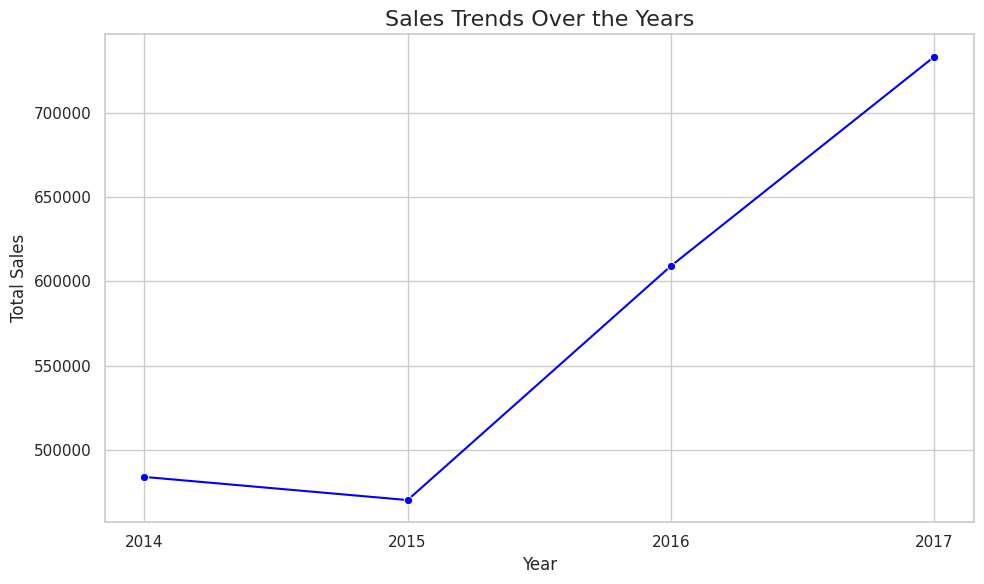

In [10]:
# set style
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

# plot line chart
sns.lineplot(data=sales_by_year, x='Year', y='Sales', marker='o', color='blue')

plt.title("Sales Trends Over the Years", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(sales_by_year['Year'].unique())  # ensure all years are shown
plt.tight_layout()
plt.show()

In [16]:
import plotly.express as px

# dictionary to map full state names → postal codes
us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA',
    'Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM',
    'New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

# add a column with postal codes
superstore['State_Code'] = superstore['State'].map(us_state_abbrev)

# aggregate sales by state postal code
state_sales = superstore.groupby("State_Code")["Sales"].sum().reset_index()

# create choropleth map for US states
fig = px.choropleth(
    state_sales,
    locations="State_Code",       # state postal codes
    locationmode="USA-states",    # important!
    color="Sales",
    hover_name="State_Code",
    hover_data={"Sales": True},
    color_continuous_scale=px.colors.sequential.Plasma,
    scope="usa",
    title="Sales Distribution by US States (Postal Codes)"
)

fig.show()

/tmp/ipykernel_1578/1985866421.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




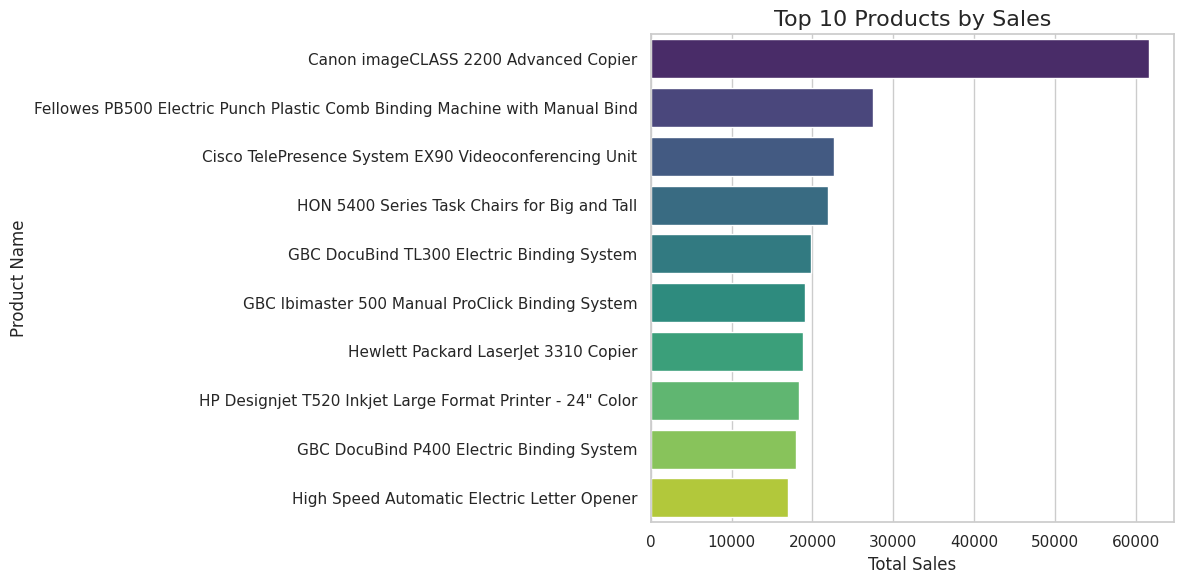

In [17]:
# aggregate sales by Product Name
product_sales = superstore.groupby("Product Name")["Sales"].sum().reset_index()

# sort descending and take top 10
top10_products = product_sales.sort_values(by="Sales", ascending=False).head(10)
# set style
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

# bar chart
sns.barplot(
    data=top10_products,
    x="Sales",
    y="Product Name",
    palette="viridis"
)

plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
# check data types
superstore["Discount"] = pd.to_numeric(superstore["Discount"], errors="coerce")
superstore["Profit"] = pd.to_numeric(superstore["Profit"], errors="coerce")

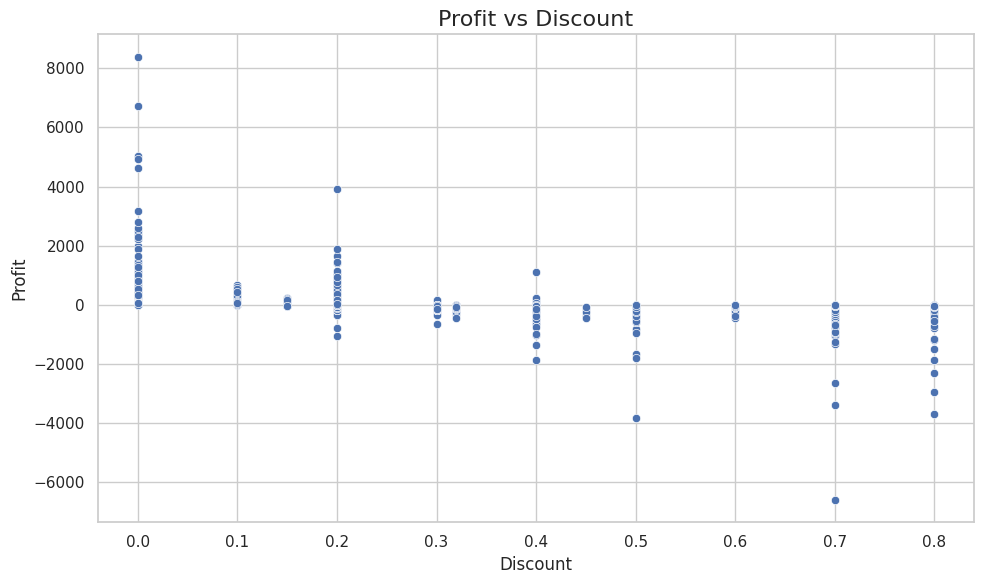

In [20]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

# scatter plot
sns.scatterplot(
    data=superstore,
    x="Discount",
    y="Profit"
)

plt.title("Profit vs Discount", fontsize=16)
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.tight_layout()
plt.show()

1. Matplotlib

Ease of Use:
Matplotlib offers fine-grained control over every element of a plot, including axes, labels, legends, and annotations. While flexible, it requires more lines of code and careful setup for styling, which can increase complexity for beginners or rapid exploratory analysis.

Effectiveness:

Highly effective for time series and trend analysis, such as plotting total sales over the years.

Allows precise customization of figures, making it suitable for report-ready or publication-quality charts.

Less efficient for statistical or comparative visualizations; relationships between variables need additional manual calculations.

Static by default; interactivity requires extra setup (e.g., %matplotlib notebook in Jupyter).

Insights from Matplotlib Visualizations:

Tracked yearly sales trends, highlighting seasonal patterns and revenue spikes.

Visualized state-level sales distribution with postal-code mapping for clarity.

Strengths: Precision, versatility, and full control over plot design.
Weaknesses: More verbose coding and limited built-in statistical features.
2. Seaborn

Ease of Use:
Seaborn provides a high-level, intuitive API with modern default aesthetics, including color palettes and grid styles. Minimal code is needed to create polished charts. Features like hue, size, and automatic regression lines simplify statistical visualization.

Effectiveness:

Excellent for exploratory data analysis and spotting patterns.

Efficient for top contributors analysis, e.g., top 10 products by sales.

Enables clear visualization of relationships, such as Profit vs Discount.

Built-in integration with Pandas DataFrames makes aggregation and plotting seamless.

Less flexible for highly customized layouts compared to Matplotlib.

Insights from Seaborn Visualizations:

Identified top-selling products and high-impact customers.

Revealed negative correlation between discounts and profit, highlighting risky product strategies.

Provided intuitive visual summaries for distributions and comparisons.

Strengths: Quick insight generation, clean aesthetics, statistical support.
Weaknesses: Limited customization for complex or publication-ready layouts.
Conclusion

Using both Matplotlib and Seaborn allowed a comprehensive understanding of the sales dataset:

Matplotlib revealed overall trends and state-level sales distribution, useful for strategic planning.

Seaborn uncovered top-performing products, high-value customers, and relationships between key metrics, helping identify areas for revenue optimization and risk mitigation.

Together, these tools provide a robust toolkit for data analysis and visualization, balancing precision, insight, and aesthetics.